In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

# Note: makes more sense to report drug-disease pairs!!!

# Translation stats

In [3]:
def to_pct(val):
    if pd.isna(val):
        return np.nan
    # already numeric: assume 0–1 are proportions, >=1 are percent values
    if isinstance(val, (int, float)):
        return float(val) * 100 if 0 <= float(val) <= 1 else float(val)
    s = str(val).strip()
    # match "(40.0%)" inside text like "6 (40.0%)"
    m = re.search(r'\(([-+]?\d*\.?\d+)\s*%?\)', s)
    if m:
        return float(m.group(1))
    # match trailing "40%" or "40.0 %"
    m = re.search(r'([-+]?\d*\.?\d+)\s*%$', s)
    if m:
        return float(m.group(1))
    # fallback: try raw float
    try:
        return float(s)
    except ValueError:
        return np.nan

In [13]:
def get_heterogeneity_stats(df, agg_dict, drug_col_name, study_id_col="PMID"):

    table_by_drug = (df
      .groupby(drug_col_name, dropna=False)
      .agg(**agg_dict)
      .reset_index()
      .rename(columns={drug_col_name: 'drug_name'}))
    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)

    # flags + aggregates for non-approved
    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)
    total_drugs = len(table_by_drug)
    
    aggregate_stats = pd.Series({
        'n_drugs_in_table': total_drugs,
        'tested_in_both_sexes': fmt_count_pct(int(per_drug_flags['tested_both_sexes'].sum()), total_drugs),
        'tested_in_>=2_species': fmt_count_pct(int(per_drug_flags['species_ge2'].sum()), total_drugs),
        'tested_in_>=2_strains': fmt_count_pct(int(per_drug_flags['strains_ge2'].sum()), total_drugs),
        'tested_with_>=2_outcomes': fmt_count_pct(int(per_drug_flags['assays_ge2'].sum()), total_drugs),
        'tested_in_>=2_countries': fmt_count_pct(int(per_drug_flags['countries_ge2'].sum()), total_drugs),
    })
    
    # study-level totals & rigor % for the filtered non-approved subset (unique studies only)
    total_studies_non = int(df[study_id_col].nunique())
    aggregate_stats.loc['total_number_of_studies'] = total_studies_non

    return aggregate_stats, table_by_drug

def pick_rig_cols(columns):
    order = [('rigor_blinding_binary','rigor_blinding'),
             ('rigor_randomization_binary','rigor_randomization'),
             ('rigor_welfare_binary','rigor_welfare')]
    picked = []
    for a,b in order:
        picked.append(a if a in columns else (b if b in columns else None))
    return picked

def pct(n, d):
    return f"{(n/d*100):.1f}%" if d > 0 else "0.0%"


def rob_percents_per_subset(df_subset, pick_rig_cols_fn):
    """Compute % of studies (unique PMIDs) with each ROB flag."""
    rb_col, rr_col, rw_col = pick_rig_cols_fn(df_subset.columns)
    rig_cols = [c for c in [rb_col, rr_col, rw_col] if c]

    if not rig_cols:
        return {"%_rigor_blinding": "0.0%", "%_rigor_randomization": "0.0%", "%_rigor_welfare": "0.0%"}

    tmp = df_subset[["PMID"] + rig_cols].copy()
    for c in rig_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce").fillna(0).astype(int).clip(0, 1)

    # One record per study: a study counts as 1 if ANY row says 1
    per_study = tmp.groupby("PMID", as_index=False)[rig_cols].max()
    n_studies = len(per_study)

    rb = per_study[rb_col].sum() if rb_col else 0
    rr = per_study[rr_col].sum() if rr_col else 0
    rw = per_study[rw_col].sum() if rw_col else 0

    return {
        "%_rigor_blinding": pct(rb, n_studies),
        "%_rigor_randomization": pct(rr, n_studies),
        "%_rigor_welfare": pct(rw, n_studies),
    }

    
def compute_experimental_chars(df, agg_dict, drug_col="unique_drug_target"):

    # FAILED DRUGS
    non_approved_studies = df[(df['translation_status'] != 'approved')].copy()
    print(f"Size of failed ds {non_approved_studies.shape} with {non_approved_studies[drug_col].nunique()} drugs and {non_approved_studies['PMID'].nunique()} studies")
    aggregate_stats_non_approved, table_by_drug_fail = get_heterogeneity_stats(non_approved_studies, agg_dict, drug_col_name=drug_col)
    # ROB
    failed_rob = rob_percents_per_subset(non_approved_studies, pick_rig_cols)
    aggregate_stats_non_approved.loc['%_rigor_blinding']     = failed_rob['%_rigor_blinding']
    aggregate_stats_non_approved.loc['%_rigor_randomization'] = failed_rob['%_rigor_randomization']
    aggregate_stats_non_approved.loc['%_rigor_welfare']       = failed_rob['%_rigor_welfare']


    # SUCCESFULL DRUGS
    approved_matches = df[(df['translation_status'] == 'approved')].copy()
    print(f"Size of approved ds {approved_matches.shape} with {approved_matches[drug_col].nunique()} drugs and {approved_matches['PMID'].nunique()} studies")
    aggregate_stats_approved, table_by_drug_appr = get_heterogeneity_stats(approved_matches, agg_dict, drug_col_name=drug_col)

    # ROB
    approved_rob = rob_percents_per_subset(approved_matches, pick_rig_cols)
    aggregate_stats_approved.loc['%_rigor_blinding']     = approved_rob['%_rigor_blinding']
    aggregate_stats_approved.loc['%_rigor_randomization'] = approved_rob['%_rigor_randomization']
    aggregate_stats_approved.loc['%_rigor_welfare']       = approved_rob['%_rigor_welfare']
    
    # -----------------------------
    # Side-by-side comparison (no .T)
    # -----------------------------
    comparison_df = pd.DataFrame({
        'Approved': aggregate_stats_approved,
        'Non-approved': aggregate_stats_non_approved
    })

    # rows for which we want the delta
    delta_rows = ['tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains', 'tested_with_>=2_outcomes', 'tested_in_>=2_countries', '%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare']
    delta_rows = [r for r in delta_rows if r in comparison_df.index]  # keep only existing
    
    # compute percentage columns for those rows
    pct_only = comparison_df.loc[delta_rows].applymap(to_pct)
    
    # add a signed percentage-point delta column: Approved - Non-approved
    comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)'] = (
        pct_only['Approved'] - pct_only['Non-approved']
    )
    
    # (optional) pretty formatting for the delta column
    comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)'] = (
        comparison_df.loc[delta_rows, 'Δ % (Apprv - Non-apprv)']
        .apply(lambda x: f"{x:+.1f} %" if pd.notna(x) else "")
    )
    
    # keep your preferred row order
    order = [
        'n_drugs_in_table',
        'total_number_of_studies',
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]

    # Optional: tidy row order
    order = [
        'n_drugs_in_table',
        'total_number_of_studies',
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
        'tested_with_>=2_outcomes', 'tested_in_>=2_countries',
        '%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare'
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]
    

    return aggregate_stats_non_approved, aggregate_stats_approved, comparison_df, table_by_drug_fail, table_by_drug_appr



def _tokens(s):
    if pd.isna(s) or not str(s).strip():
        return set()
    return {t.strip() for t in _splitter.split(str(s)) if t.strip()}

def _strip_prefix_lower(x):
    x = x.lower().strip()
    x = re.sub(r'^(sex|species|strain|assay|country|first_author_country)[\s\-_]*', '', x)
    return x


def _sex_norms(sex_str):
    toks = {_strip_prefix_lower(t) for t in _tokens(sex_str)}
    out = set()
    for t in toks:
        if 'both' in t:        out.add('both')
        elif 'male' in t:      out.add('male')
        elif 'female' in t:    out.add('female')
        elif 'not' in t and 'report' in t:
            out.add('not-reported')
        elif t:
            out.add(t)
    return out
    
def compute_flags(row):
    sexes = _sex_norms(row.get('animal_sex'))
    both_sexes = ('both' in sexes) or ('male' in sexes and 'female' in sexes)

    species = _clean_set(row.get('animal_species'), exclude={'other'})  # exclude species-other
    strains = _clean_set(row.get('animal_strain'),  exclude={'unlabeled','unlabelled'})
    assays  = _clean_set(row.get('assay_type'),     exclude={'unlabeled','unlabelled'})
    countries = _clean_set(row.get('first_author_country'), exclude={'unlabeled','unlabelled'})

    return pd.Series({
        'tested_both_sexes': int(both_sexes),
        'species_unique': len(species),
        'species_ge2': int(len(species) >= 2),
        'strain_unique': len(strains),
        'strains_ge2': int(len(strains) >= 2),
        'assay_unique': len(assays),
        'assays_ge2': int(len(assays) >= 2),
        'country_unique': len(countries),
        'countries_ge2': int(len(countries) >= 2),
    })

def fmt_count_pct(count, total):
    pct = (count / total * 100) if total > 0 else 0
    return f"{count} ({pct:.1f}%)"
    
def _clean_set(cat_str, exclude=None):
    exclude = exclude or set()
    toks = {_strip_prefix_lower(t) for t in _tokens(cat_str)}
    return {t for t in toks if t and t not in exclude}
    
def unique_concat(series):
    vals = set()
    for x in series.dropna():
        for t in _splitter.split(str(x)):
            if t.strip():
                vals.add(t.strip())
    return ', '.join(sorted(vals)) if vals else ''

_splitter = re.compile(r'[|,]')

## load data

In [5]:
# FROM /10_use_case_disease_focus/Translation_03_Prep_Datasets.ipynb
preclin_dataset_to_clinical= pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/data/preclin_dataset_to_clinical.csv")

In [6]:
rigor_cols = ['rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size']
for col in rigor_cols:
    preclin_dataset_to_clinical[col + '_binary'] = preclin_dataset_to_clinical[col].apply(lambda x: 1 if isinstance(x, str) and 'present' in x else 0)

In [7]:
preclin_dataset_to_clinical.columns

Index(['PMID', 'title', 'merged_mondo_label', 'merged_umls_label',
       'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size',
       'animal_species', 'animal_sex', 'animal_strain', 'animal_number',
       'assay_type', 'first_author_country', 'drug_term_umls_norm',
       'n_unique_trials', 'median_trial_duration_years',
       'at_least_one_phase3_completed', 'at_least_one_phase4',
       'min_phase_nct_id', 'min_phase', 'min_phase_start_year',
       'max_phase_nct_id', 'max_phase', 'max_phase_start_year',
       'earliest_trial_nct_id', 'earliest_trial_phase',
       'earliest_trial_start_year', 'shortest_trial_nct_id',
       'shortest_trial_years', 'longest_trial_nct_id', 'longest_trial_years',
       'fda_merged_umls_label', 'fda_year', 'fda_sponsor_name',
       'fda_application_number', 'fda_AP', 'translation_status',
       'rigor_blinding_binary', 'rigor_randomization_binary',
       'rigor_welfare_binary', 'sample_size_binary'],
      dtype='object')

In [8]:
preclin_dataset_to_clinical.head()

,PMID,title,merged_mondo_label,merged_umls_label,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,...,fda_merged_umls_label,fda_year,fda_sponsor_name,fda_application_number,fda_AP,translation_status,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary
0,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,...,NaN,NaN,NaN,NaN,False,approved,0,0,0,0
1,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,mouse,not-reported,...,NaN,NaN,NaN,NaN,False,approved,0,0,0,0
2,1000338,A morphometric investigation of the duodenal m...,vitamin D deficiency,VITAMIN D,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,rat,not-reported,...,NaN,NaN,NaN,NaN,False,approved,0,1,0,0
3,10022166,Prenatal vitamin E treatment improves lung gro...,congenital diaphragmatic hernia,Vitamin E,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,female,...,NaN,NaN,NaN,NaN,False,approved,0,0,0,0
4,10022175,Meconium stimulates a pro-inflammatory respons...,intestinal obstruction in the newborn due to g...,pkc inhibitor,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rabbit,not-reported,...,NaN,NaN,NaN,NaN,False,approved,0,0,0,0


In [14]:
agg_dict = {
    'animal_sex': ('animal_sex', unique_concat),
    'animal_strain': ('animal_strain', unique_concat),
    'animal_species': ('animal_species', unique_concat),
    'assay_type': ('assay_type', unique_concat),
    'first_author_country': ('first_author_country', unique_concat),
    #'n_studies': ('single_drug', 'size'),
}

aggregate_stats_non_approved, aggregate_stats_approved, comparison_df, table_by_drug_fail, table_by_drug_appr = compute_experimental_chars(preclin_dataset_to_clinical, agg_dict, drug_col="drug_term_umls_norm")

comparison_df

Size of failed ds (104701, 42) with 2532 drugs and 85257 studies
Size of approved ds (261808, 42) with 2111 drugs and 173139 studies


,Approved,Non-approved,Δ % (Apprv - Non-apprv)
n_drugs_in_table,2111,2532,NaN
total_number_of_studies,173139,85257,NaN
tested_in_both_sexes,1517 (71.9%),1477 (58.3%),+13.6 %
tested_in_>=2_species,1755 (83.1%),1848 (73.0%),+10.1 %
tested_in_>=2_strains,1756 (83.2%),1833 (72.4%),+10.8 %
tested_with_>=2_outcomes,2007 (95.1%),2348 (92.7%),+2.4 %
tested_in_>=2_countries,1815 (86.0%),1906 (75.3%),+10.7 %
%_rigor_blinding,20.8%,18.0%,+2.8 %
%_rigor_randomization,35.1%,34.3%,+0.8 %
%_rigor_welfare,71.5%,69.7%,+1.8 %


## top entities plots

In [41]:
import sys
from pathlib import Path

# 1. Figure out where you are
notebook_dir = Path().cwd()  

# 2. Build the path to the module folder
viz_folder = notebook_dir.parent / "06_preclin_clinic_join"

# 3. Insert it onto sys.path
sys.path.insert(0, str(viz_folder.resolve()))

# 4. Now import
from viz_data import plot_top_entities_side_by_side

In [42]:
conditions_col_to_use = "disease_term_mondo_parent_clean"
drugs_col_to_use = "drug_term_umls_norm"

In [43]:
preclin_dataset_to_clinical[preclin_dataset_to_clinical[drugs_col_to_use].astype(str).str.contains(r"\|")]

,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,...,earliest_trial_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary


In [44]:
preclin_dataset_to_clinical.shape

(339072, 36)

In [45]:
preclin_dataset_to_clinical.head()

,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,...,earliest_trial_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,male,...,2008.0,NCT01455376,0.25,NCT01573507,5.72,failed,0,0,0,0
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rabbit,not-reported,...,2001.0,NCT01054859,0.00,NCT00816231,13.12,approved,0,0,0,0
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,...,2000.0,NCT02283827,0.16,NCT04573803,7.00,approved,0,0,1,0
4,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Pentobarbital,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,...,2002.0,NaN,NaN,NCT00622570,5.59,failed,0,0,1,0
8,3420,"Anti-arrhythmic action of nadolol, a beta-adre...",ventricular arrhythmias due to cardiac ryanodi...,Propranolol,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"cat, dog",male,...,2001.0,NCT00093860,0.41,NCT01988883,10.17,approved,0,0,0,0


In [46]:
preclin_dataset_to_clinical.columns

Index(['PMID', 'title', 'disease_term_mondo_norm', 'drug_term_umls_norm',
       'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size',
       'animal_species', 'animal_sex', 'animal_age', 'animal_strain',
       'animal_number', 'assay_type', 'first_author_country',
       'disease_term_mondo_parent_clean', 'n_unique_trials',
       'median_trial_duration_years', 'min_phase_nct_id', 'min_phase',
       'min_phase_start_year', 'max_phase_nct_id', 'max_phase',
       'max_phase_start_year', 'earliest_trial_nct_id', 'earliest_trial_phase',
       'earliest_trial_start_year', 'shortest_trial_nct_id',
       'shortest_trial_years', 'longest_trial_nct_id', 'longest_trial_years',
       'study_classification', 'rigor_blinding_binary',
       'rigor_randomization_binary', 'rigor_welfare_binary',
       'sample_size_binary'],
      dtype='object')

In [47]:
preclin_dataset_to_clinical.to_csv("data/preclin_dataset_to_clinical.csv", index=False)

In [48]:
preclin_dataset_to_clinical_exploded_disease = preclin_dataset_to_clinical.copy()
preclin_dataset_to_clinical_exploded_disease[conditions_col_to_use] = preclin_dataset_to_clinical[conditions_col_to_use].str.split("|")
preclin_dataset_to_clinical_exploded_disease = preclin_dataset_to_clinical_exploded_disease.explode(conditions_col_to_use, ignore_index=True)
preclin_dataset_to_clinical_exploded_disease[conditions_col_to_use] = preclin_dataset_to_clinical_exploded_disease[conditions_col_to_use].str.strip().str.title()

In [49]:
preclin_dataset_to_clinical.shape, preclin_dataset_to_clinical_exploded_disease.shape

((339072, 36), (720054, 36))

In [50]:
preclin_dataset_to_clinical[
    preclin_dataset_to_clinical['disease_term_mondo_parent_clean']
    .str.contains("thoracic cancer", case=False, na=False)
]

,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,...,earliest_trial_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years,study_classification,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary,sample_size_binary
411,109329,Hormonal regulation in two rat mammary cancer ...,breast cancer,Androgen,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,not-reported,...,2006.0,NCT00512707,3.50,NCT00512707,3.50,approved,0,0,0,0
412,109329,Hormonal regulation in two rat mammary cancer ...,breast cancer,GLUCOCORTICOIDS,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,not-reported,...,2007.0,NCT03745586,2.25,NCT05395949,8.08,approved,0,0,0,0
413,109329,Hormonal regulation in two rat mammary cancer ...,breast cancer,Dexamethasone,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,not-reported,...,2000.0,NCT03194594,0.11,NCT01868269,18.03,approved,0,0,0,0
467,123645,Effect of estrogen treatment on DMBA-induced m...,breast cancer|mammary,Estrogens,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,not-reported,...,2001.0,NCT02792517,0.57,NCT00059228,13.58,approved,0,0,0,0
1742,793479,Chemoimmunotherapy of syngeneic mouse mammary ...,carcinoma|breast carcinoma,Methotrexate,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,mouse,female,...,2001.0,NCT02074319,1.66,NCT01190930,17.64,approved,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
920392,38963035,Improved efficacy of cisplatin delivery by pea...,non-small cell lung carcinoma|lung carcinoma,Cisplatin,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,...,2001.0,NCT00005850,2.08,NCT00031590,10.08,failed,0,1,1,0
920393,38963035,Improved efficacy of cisplatin delivery by pea...,non-small cell lung carcinoma|lung carcinoma,Cisplatin,blinding-not-reported,randomization-present,welfare-present,sample-size-not-reported,mouse,male,...,2001.0,NCT00005850,2.08,NCT00031590,10.08,failed,0,1,1,0
920516,38966167,Evaluation of antitumor potential of an anti-g...,lung neoplasm|non-small cell lung carcinoma|lu...,Monoclonal antibody,blinding-not-reported,randomization-present,welfare-not-reported,sample-size-not-reported,mouse,male,...,2006.0,NCT01579383,1.00,NCT01217437,10.60,approved,0,1,0,0
920536,38967523,METTL1/FOXM1 promotes lung adenocarcinoma prog...,lung adenocarcinoma,gefitinib,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,mouse,both,...,2004.0,NaN,NaN,NCT00234442,1.58,failed,0,0,1,0


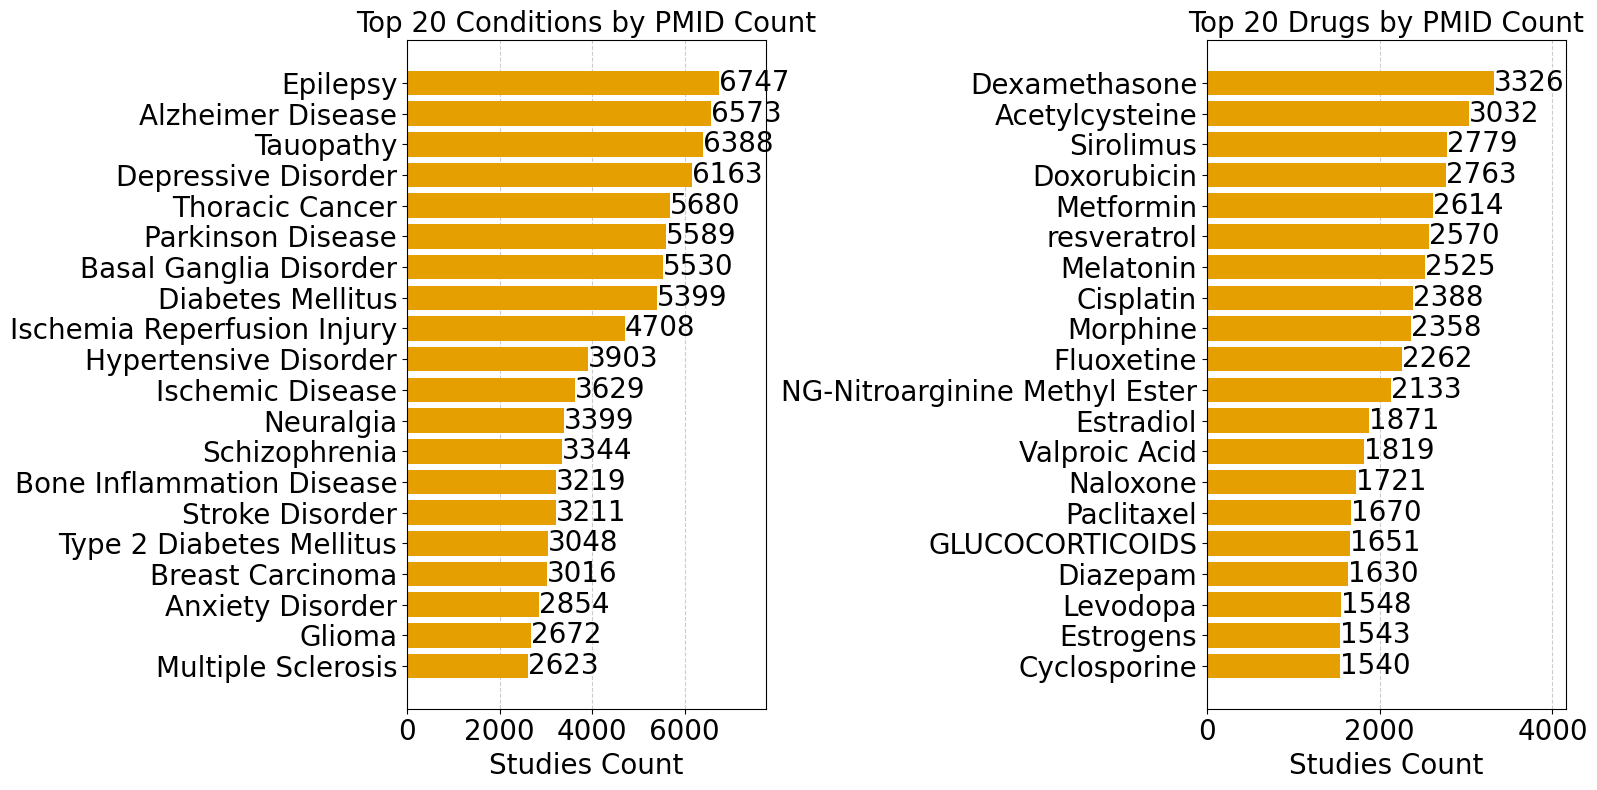

In [51]:
plot_top_entities_side_by_side(preclin_dataset_to_clinical_exploded_disease, 'PMID', conditions_col_to_use, drugs_col_to_use, save=True, save_path="viz/", top_n=20, color_code='#E69F00', viz_name_suffix='preclinical_to_clinical_disease_term_mondo_parent_clean', save_to="png", custom_fontsize=20)

# Drug-Disease Pairs

In [52]:
preclin_dataset.head()

,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,first_author_country,disease_term_mondo_parent_clean
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,male,not reported,Sprague-Dawley,not reported,Histology,unlabeled,ischemic disease
1,2163,Methanol poisoning. I. The role of formic acid...,metabolic acidosis|poisoning,Fomepizole,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,monkey,both,2.2-6.5 years,Sprague-Dawley,not reported,"Behavioral, Molecular & Cellular",unlabeled,metabolic acidosis|poisoning
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rabbit,not-reported,not reported,not reported,not reported,Molecular & Cellular,unlabeled,hypochromic anemia
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,not reported,not reported,2.0,not reported,unlabeled,epilepsy
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Pentobarbital,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,not reported,not reported,2.0,not reported,unlabeled,epilepsy


In [53]:
df_clin_entities_metadata.head()

,nct_id,drug_term_umls_norm,disease_term_mondo_norm,start_date,completion_date,overall_status,phase
0,NCT00000307,Naltrexone,alcohol-related disorders|alcoholic cocaine de...,2003-04-30,2007-04-30,Completed,Phase 2
1,NCT00000333,Atropine|Benztropine|Benztropine|da reuptake i...,cocaine|cocaine dependence,2001-05-31,2003-04-30,Completed,Phase 2
2,NCT00000428,Amitriptyline|amitriptyline plus fluoxitine|fl...,fibromyalgia,2000-09-30,2004-03-31,Completed,Phase 4
3,NCT00000439,depacon|Valproate Sodium|Valproate|Valproic Acid,alcohol abuse|bipolar alcoholics|bipolar disor...,2000-10-31,2003-08-31,Completed,Phase 2
4,NCT00001956,Ketorolac|Lidocaine|Midazolam|sedative,hyperalgesia|oral surgery|obsolete disorder in...,2000-01-31,2005-02-28,Completed,Phase 2


Shape of preclinical_df: (951006, 16), 340380 unique PMIDs


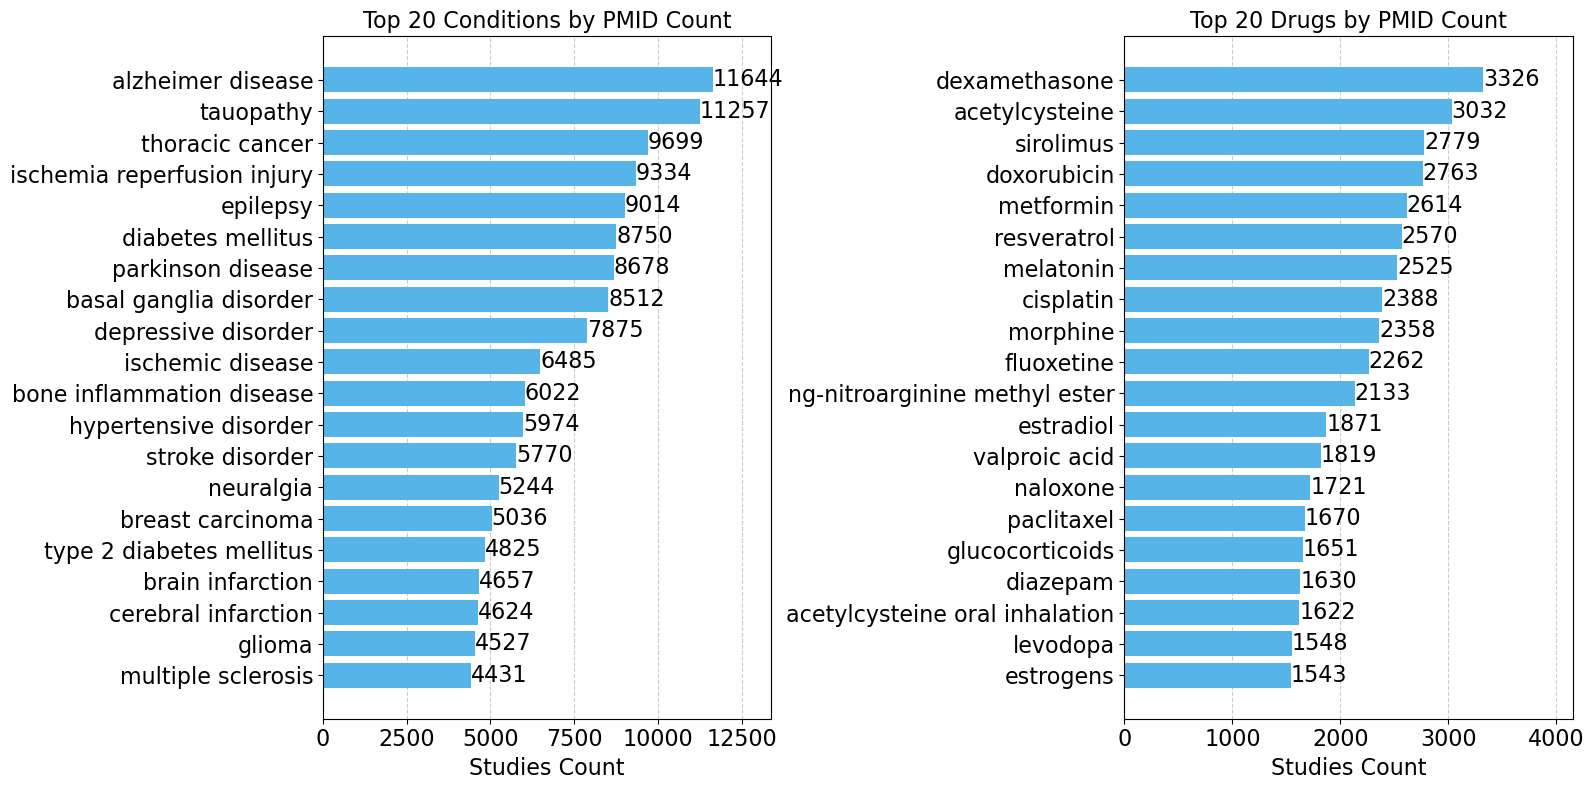

In [54]:
import pandas as pd
import numpy as np
from viz_data import viz_joined_preclin_clinical
from viz_data import plot_top_entities_side_by_side

# ------------------------- #
#        LOAD DATA         #
# ------------------------- #

FILE_PRECLINICAL_LINKING = "04_normalization/data/mapped_all/mapped_preclinical_data_with_mondo_parents_mental_disorder.csv"
FILE_CLINICAL_LINKING = "04_normalization/data/mapped_all/mapped_clinical_data_with_mondo_parents_mental_disorder.csv"
FILE_CLINICAL_METADATA = "06_preclin_clinic_join/data/clinical/clinical_nct_docs_metadata_20240313.csv"

OUTPUT_DIR = "out/joined_data/"

conditions_col_to_use = "disease_term_mondo_parent_clean" #"merged_mondo_label" # #"linkbert_mapped_conditions" # disease_term_mondo_norm
drugs_col_to_use =  "drug_term_umls_norm" #"linkbert_mapped_drugs" #"drug_term_umls_norm"

conditions_col_to_use_clinical =  "disease_term_mondo_norm"#"linkbert_aact_mapped_conditions" #"disease_term_mondo_norm"
drugs_col_to_use_clinical =  "drug_term_umls_norm" #"linkbert_aact_mapped_drugs" # "drug_term_umls_norm"

# --- Load Preclinical Data ---
preclinical_df = preclin_dataset.copy() #pd.read_csv(FILE_PRECLINICAL_LINKING)
print(f"Shape of preclinical_df: {preclinical_df.shape}, {preclinical_df.PMID.nunique()} unique PMIDs")

# Split and explode conditions and drugs
preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.split("|")
preclinical_df = preclinical_df.explode(conditions_col_to_use, ignore_index=True)

preclinical_df[drugs_col_to_use] = preclinical_df[drugs_col_to_use].str.split("|")
preclinical_df = preclinical_df.explode(drugs_col_to_use, ignore_index=True)

preclinical_df = preclinical_df.drop_duplicates()

# Strip whitespace and convert to lowercase
preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.strip().str.lower()
preclinical_df[drugs_col_to_use] = preclinical_df[drugs_col_to_use].str.strip().str.lower()

# Create disease-drug key
preclinical_df['disease<>drug'] = (
    preclinical_df[conditions_col_to_use] + " <> " + preclinical_df[drugs_col_to_use]
)

plot_top_entities_side_by_side(preclinical_df, id_column='PMID', condition_column=conditions_col_to_use, drug_column=drugs_col_to_use, color_code='#56B4E9', save_path="viz/")




Shape of clinical_df: (18609, 7), 18609 unique NCTIDs


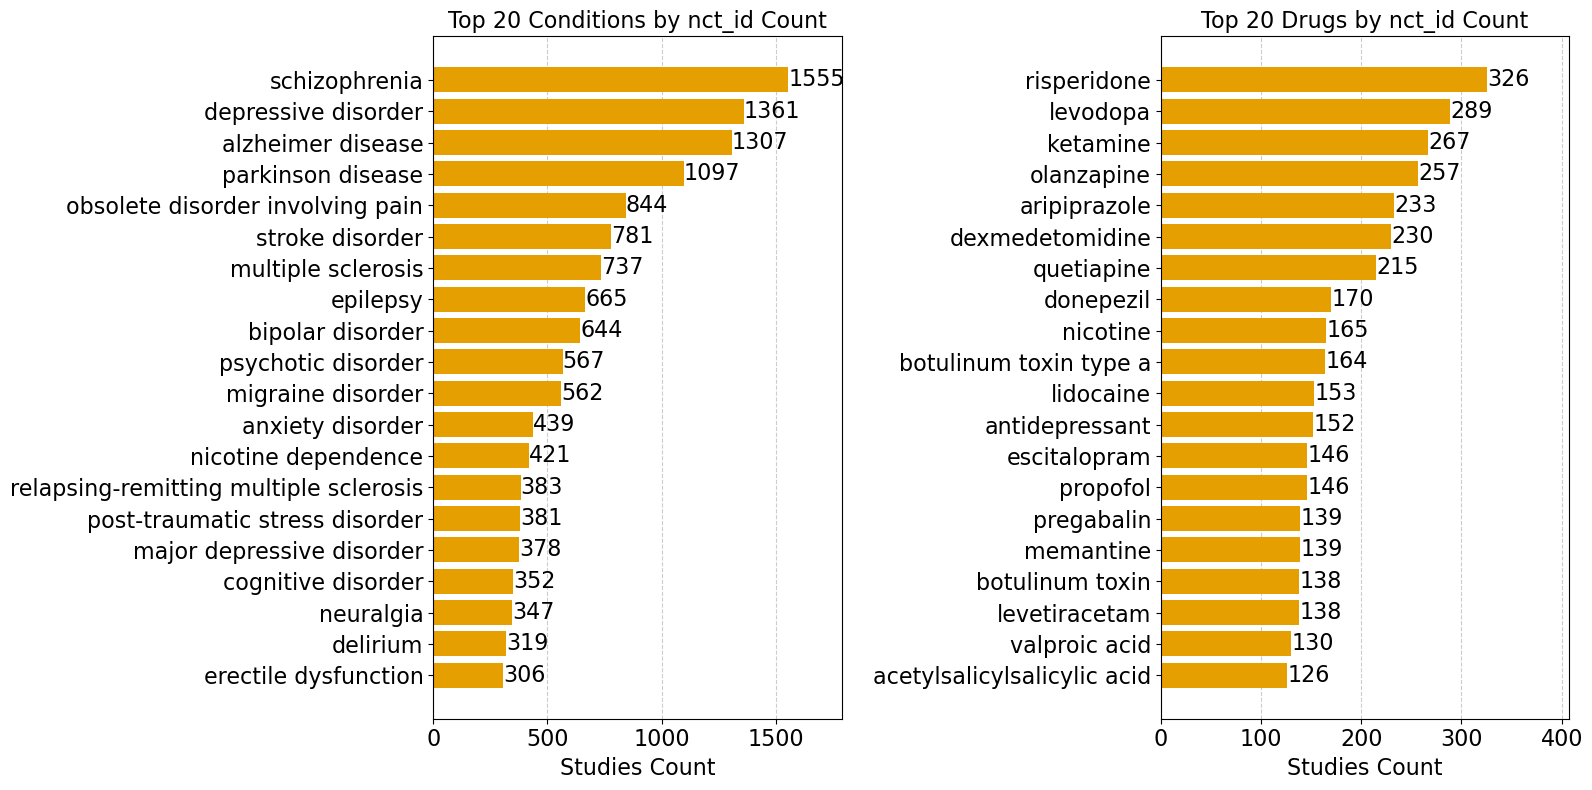

In [55]:
# --- Load Clinical Data ---
clinical_df = df_clin_entities_metadata.copy() #pd.read_csv(FILE_CLINICAL_LINKING)
print(f"Shape of clinical_df: {clinical_df.shape}, {clinical_df.nct_id.nunique()} unique NCTIDs")

clinical_df[conditions_col_to_use_clinical] = clinical_df[conditions_col_to_use_clinical].str.split("|")
clinical_df = clinical_df.explode(conditions_col_to_use_clinical, ignore_index=True)

clinical_df[drugs_col_to_use_clinical] = clinical_df[drugs_col_to_use_clinical].str.split("|")
clinical_df = clinical_df.explode(drugs_col_to_use_clinical, ignore_index=True)

# Strip whitespace and convert to lowercase
clinical_df[conditions_col_to_use_clinical] = clinical_df[conditions_col_to_use_clinical].str.strip().str.lower()
clinical_df[drugs_col_to_use_clinical] = clinical_df[drugs_col_to_use_clinical].str.strip().str.lower()

# Create disease-drug key
clinical_df['disease<>drug'] = (
    clinical_df[conditions_col_to_use_clinical] + " <> " + clinical_df[drugs_col_to_use_clinical]
)

plot_top_entities_side_by_side(clinical_df, id_column='nct_id', condition_column=conditions_col_to_use_clinical, drug_column=drugs_col_to_use_clinical, viz_name_suffix='clinical', save_path="viz/")



In [56]:
# ------------------------- #
#     AGGREGATE & MERGE     #
# ------------------------- #
def aggregate_and_merge(clinical_df, preclinical_df, 
                        clinical_key_col, clinical_doc_id_col, 
                        preclinical_key_col, preclinical_doc_id_col,
                        preclinical_disease_col, preclinical_drug_col):
    """
    Aggregates and merges clinical and preclinical data on a shared normalized key.

    Parameters:
    ----------
    clinical_df : pd.DataFrame
        DataFrame containing clinical study data, including a merge key and document-level info.

    preclinical_df : pd.DataFrame
        DataFrame containing preclinical (animal study) data with a similar merge key and document info.

    clinical_key_col : str
        Column name in the clinical dataframe that holds the disease<>drug key used for merging.

    clinical_doc_id_col : str
        Column name in the clinical dataframe representing document IDs (e.g., NCT IDs).

    preclinical_key_col : str
        Column name in the preclinical dataframe that holds the disease<>drug key used for merging.

    preclinical_doc_id_col : str
        Column name in the preclinical dataframe representing document IDs (e.g., PMIDs).

    preclinical_disease_col : str
        Column name in the preclinical dataframe containing the mapped disease name(s).

    preclinical_drug_col : str
        Column name in the preclinical dataframe containing the mapped drug name(s).

    Returns:
    -------
    pd.DataFrame
        A merged DataFrame containing aggregated clinical and preclinical data by normalized key.
        Includes counts of associated documents and selected metadata like disease, drug, phase, and status.
    """
    clinical_unique = (
        clinical_df
        .sort_values(clinical_doc_id_col)  # optional: enforce a deterministic order
        .drop_duplicates(subset=[clinical_key_col, clinical_doc_id_col], keep='first')
    )
    # === Aggregate clinical data by key ===
    clinical_agg = (
            clinical_unique
            .groupby(clinical_key_col)
            .agg({
                clinical_doc_id_col: list,
                'phase':              list,
                'overall_status':     list
            })
            .reset_index()
            )
        

    # Rename columns for clarity and consistency
    clinical_agg.rename(columns={
        clinical_key_col: 'normalized_key',
        clinical_doc_id_col: 'clinical_doc_ids'
    }, inplace=True)

    # Add count of clinical documents per key
    clinical_agg['clinical_count'] = clinical_agg['clinical_doc_ids'].apply(len)

    # === Aggregate preclinical data by key ===
    preclinical_agg = preclinical_df.groupby(preclinical_key_col).agg({
        preclinical_doc_id_col: list,
        preclinical_disease_col: 'first',
        preclinical_drug_col: 'first'
    }).reset_index()

    # Rename columns for consistency
    preclinical_agg.rename(columns={
        preclinical_key_col: 'normalized_key',
        preclinical_doc_id_col: 'preclinical_doc_ids',
        preclinical_disease_col: 'disease',
        preclinical_drug_col: 'drug'
    }, inplace=True)

    # Add count of preclinical documents per key
    preclinical_agg['preclinical_count'] = preclinical_agg['preclinical_doc_ids'].apply(len)

    # === Merge clinical and preclinical aggregates on the normalized key ===
    merged_df = pd.merge(clinical_agg, preclinical_agg, on='normalized_key', how='outer')

    return merged_df

def clean_and_sort_study_data(df):
    """
    Cleans and sorts a merged clinical/preclinical DataFrame by removing invalid rows
    and ordering by study counts.

    Specifically:
    - Sorts the DataFrame in descending order of 'clinical_count' and 'preclinical_count'.
    - Removes rows where either 'clinical_count' or 'preclinical_count' is NaN.
    - Removes rows where the 'drug' name is missing or has 3 or fewer characters.
    - Prints the shape before and after filtering for transparency.

    Parameters:
    ----------
    df : pd.DataFrame
        A DataFrame containing 'clinical_count', 'preclinical_count', and 'drug'.

    Returns:
    -------
    pd.DataFrame
        The cleaned and sorted DataFrame.
    """
    print(f'Input shape of merged for cleaning: {df.shape}')

    # Sort by descending clinical and preclinical study counts
    sorted_df = df.sort_values(
        by=['clinical_count', 'preclinical_count'],
        ascending=[False, False]
    )

    # Remove rows with missing study counts
    filtered_df = sorted_df.dropna(subset=['clinical_count', 'preclinical_count'])

    # Remove rows with invalid or too-short drug names
    filtered_df = filtered_df[
        filtered_df['drug'].apply(lambda x: isinstance(x, str) and len(x.strip()) > 3)
    ]

    print(f'Shape after filtering empty counts and short drugs: {filtered_df.shape}')
    return filtered_df


# Print unique disease-drug pairs from clinical and preclinical
# Print unique disease-drug pairs from clinical and preclinical
# Preclinical Stats
print("----- Preclinical Stats: -----")
print("Unique pmid in preclinical data:")
print(preclinical_df['PMID'].nunique())
print("Unique disease-drug pairs in preclinical data:")
preclinical_unique_pairs = preclinical_df['disease<>drug'].value_counts().reset_index()
preclinical_unique_pairs.columns = ['disease<>drug', 'count']
print(preclinical_unique_pairs.shape)

print("Unique disease-drug pairs with count larger than 1 in preclinical data:")
preclinical_unique_pairs_count = preclinical_unique_pairs[preclinical_unique_pairs['count'] > 1]
print(preclinical_unique_pairs_count.shape)

# Save unique pairs to CSV
preclinical_unique_pairs.to_csv(f'{OUTPUT_DIR}preclinical_unique_pairs.csv', index=False)

# Clinical Stats
print("----- Clinical Stats: -----")
print("Unique nct_id in clinical data:")
print(clinical_df['nct_id'].nunique())
print("Unique disease-drug pairs in clinical data:")
clinical_unique_pairs = clinical_df['disease<>drug'].value_counts().reset_index()
clinical_unique_pairs.columns = ['disease<>drug', 'count']
print(clinical_unique_pairs.shape)

print("Unique disease-drug pairs with count larger than 1 in clinical data:")
clinical_unique_pairs_count = clinical_unique_pairs[clinical_unique_pairs['count'] > 1]
print(clinical_unique_pairs_count.shape)

# Save unique pairs to CSV
clinical_unique_pairs.to_csv(f'{OUTPUT_DIR}clinical_unique_pairs.csv', index=False)

# Apply aggregation + filtering
merged_df = aggregate_and_merge(
    clinical_df=clinical_df,
    preclinical_df=preclinical_df,
    clinical_key_col='disease<>drug',
    clinical_doc_id_col='nct_id',
    preclinical_key_col='disease<>drug',
    preclinical_doc_id_col='PMID',
    preclinical_disease_col=conditions_col_to_use, 
    preclinical_drug_col=drugs_col_to_use
)

filtered_df = clean_and_sort_study_data(merged_df)

print("----- Joined Stats: -----")
print(f"Filtered shape: {filtered_df.shape}")

# Flatten and count unique clinical and preclinical IDs
clinical_ids = filtered_df['clinical_doc_ids'].dropna().explode()
preclinical_ids = filtered_df['preclinical_doc_ids'].dropna().explode()

print(f"Unique clinical doc IDs after merge: {clinical_ids.nunique()}")
print(f"Unique preclinical doc IDs after merge: {preclinical_ids.nunique()}")

# ------------------------- #
#   ADD INSIGHTS / EXPORT   #
# ------------------------- #

phase_order = {
    'Early Phase 1': 0,
    'Phase 1': 1,
    'Phase 1/Phase 2': 1.5,
    'Phase 2': 2,
    'Phase 2/Phase 3': 2.5,
    'Phase 3': 3,
    'Phase 4': 4,
    'Not Applicable': -1  # Lowest value to ignore in max comparison
}

# Get max phase for each row
def get_max_phase(phases):
    max_val = -1
    max_phase = 'Not Applicable'
    for phase in phases:
        val = phase_order.get(phase, -1)
        if val > max_val:
            max_val = val
            max_phase = phase
    return max_phase

filtered_df['max_phase'] = filtered_df['phase'].apply(get_max_phase)

# Identify studies with Phase 3 or 4 trials
filtered_df['at_least_one_phase3'] = filtered_df['phase'].apply(
    lambda phases: any("Phase 3" in str(p) for p in phases)
)

filtered_df['at_least_one_phase4'] = filtered_df['phase'].apply(
    lambda phases: any("Phase 4" in str(p) for p in phases)
)

# Summary stats
total = len(filtered_df)
pct_phase3 = (filtered_df['at_least_one_phase3'].sum() / total) * 100
pct_phase4 = (filtered_df['at_least_one_phase4'].sum() / total) * 100

print(f"Percentage with Phase 3: {pct_phase3:.2f}%")
print(f"Percentage with Phase 4: {pct_phase4:.2f}%")

# Export for manual review
output_path = f"{OUTPUT_DIR}condition_clinical_and_preclinical_{total}_psychiatric.csv"
filtered_df.to_csv(output_path, index=False)


----- Preclinical Stats: -----
Unique pmid in preclinical data:
340380
Unique disease-drug pairs in preclinical data:
(1330449, 2)
Unique disease-drug pairs with count larger than 1 in preclinical data:
(170464, 2)
----- Clinical Stats: -----
Unique nct_id in clinical data:
18609
Unique disease-drug pairs in clinical data:
(92187, 2)
Unique disease-drug pairs with count larger than 1 in clinical data:
(14323, 2)
Input shape of merged for cleaning: (1411588, 9)
Shape after filtering empty counts and short drugs: (10832, 9)
----- Joined Stats: -----
Filtered shape: (10832, 9)
Unique clinical doc IDs after merge: 12078
Unique preclinical doc IDs after merge: 60358
Percentage with Phase 3: 32.34%
Percentage with Phase 4: 29.82%


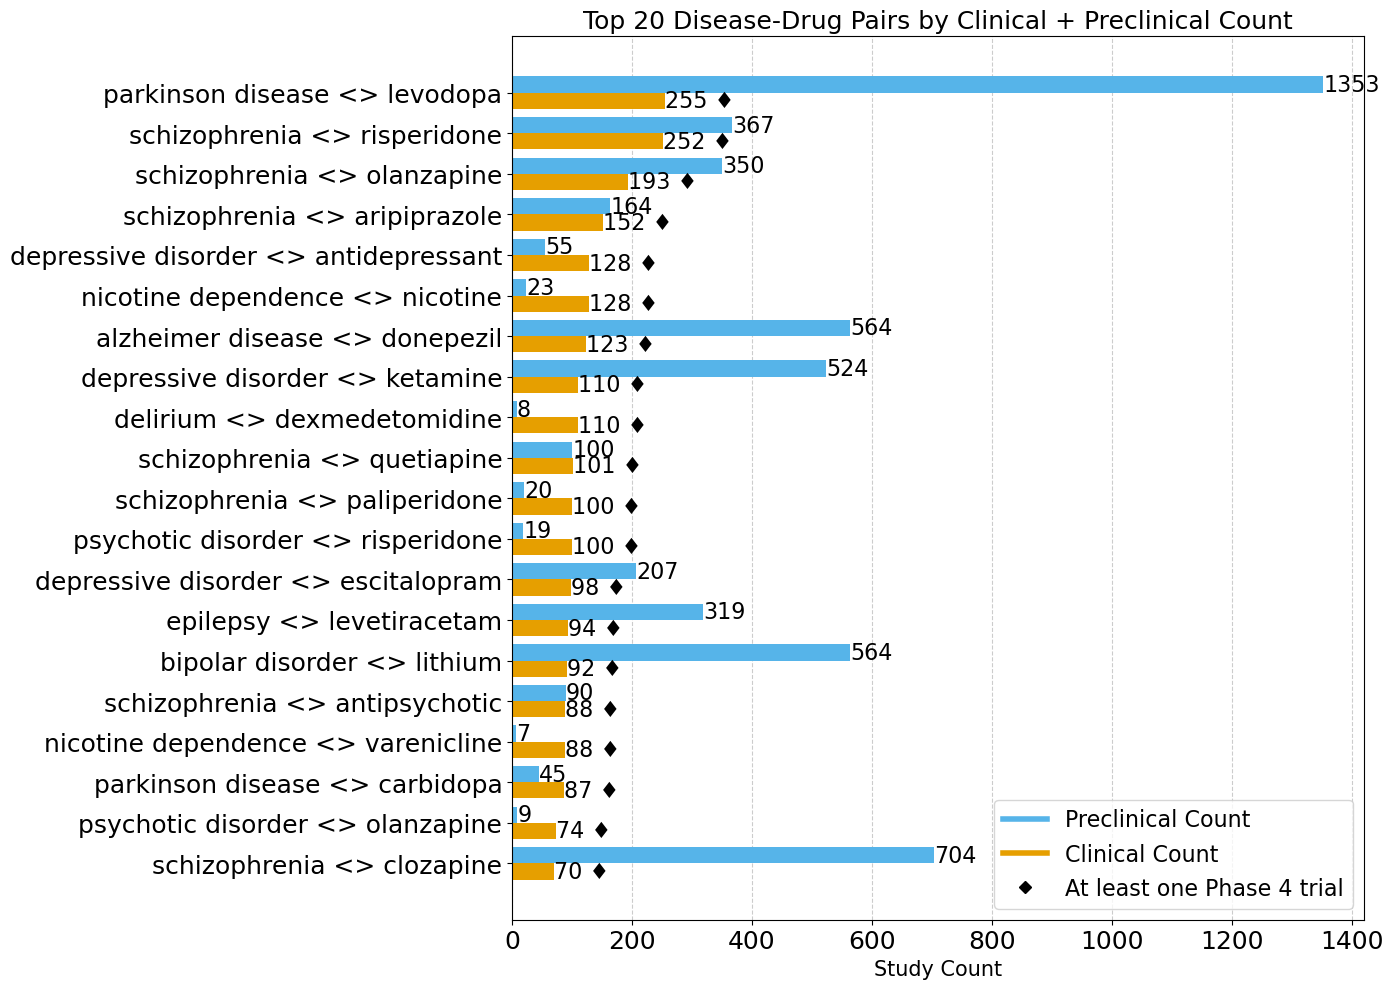

In [60]:
import matplotlib.pyplot as plt
def viz_joined_preclin_clinical(filtered_df, normalized_key="normalized_condition", additional_sort_by="both", translation_column=None, top_n=25, fig_name_suffix='', save_to="png", save_path="06_preclin_clinic_join/viz"):
    """
    Visualizes the top N normalized conditions with preclinical and clinical counts as horizontal bars.

    Parameters:
    - filtered_df (pd.DataFrame): DataFrame containing the counts and normalized keys.
    - normalized_key (str): Column name for the key (e.g., condition, drug).
    - additional_sort_by (str): Sorting criterion - "both", "clinical_count", or "preclinical_count".
    - translation_column (str or None): Column name indicating whether a symbol should be added for clinical count.
    - top_n (int): Number of top records to display.

    Returns:
    - None: Displays the plot.
    """
    if additional_sort_by == "both":
        top_n_df = filtered_df.head(top_n)
        title_str = "Clinical + Preclinical Count"
    elif additional_sort_by == "clinical_count":
        top_n_df = filtered_df.sort_values(by='clinical_count', ascending=False).head(top_n)
        title_str = "Clinical Count"
    elif additional_sort_by == "tail":
        top_n_df = filtered_df.tail(top_n)
        title_str = "Clinical + Preclinical Count Tail"
    else:
        top_n_df = filtered_df.sort_values(by='preclinical_count', ascending=False).head(top_n)
        title_str = "Preclinical Count"

    # Data for plotting
    conditions = top_n_df[normalized_key]
    clinical_counts = top_n_df['clinical_count']
    preclinical_counts = top_n_df['preclinical_count']
    
    # Bar positions
    y_positions = np.arange(len(conditions))  # Position for each condition
    bar_width = 0.4  # Width of the bars
    
    # Plotting
    plt.figure(figsize=(14, 10))
    plt.barh(y_positions - bar_width / 2, preclinical_counts, height=bar_width, label='Preclinical Count', color="#56B4E9",zorder=2)
    plt.barh(y_positions + bar_width / 2, clinical_counts, height=bar_width, label='Clinical Count', color="#E69F00",zorder=2)

    # Add labels and optional symbol to each bar
    for i in range(len(conditions)):
        plt.text(preclinical_counts.iloc[i], y_positions[i] - bar_width / 2, f'{preclinical_counts.iloc[i]:.0f}', va='center',fontsize=16)
        
        clinical_text = f'{clinical_counts.iloc[i]:.0f}'
        if translation_column and top_n_df[translation_column].iloc[i]:
            clinical_text += " ♦"  # Add diamond symbol
        plt.text(clinical_counts.iloc[i], y_positions[i] + bar_width / 2, clinical_text, va='center', fontsize=16)

    # Adding labels and legend
    plt.yticks(y_positions, conditions)
    plt.xlabel('Study Count', fontsize=15)
    #plt.ylabel('Normalized Condition')
    plt.title(f'Top {top_n} Disease-Drug Pairs by {title_str}', fontsize=18)
    
    # Update legend to include diamond explanation if translation_column is provided
    if translation_column:
        plt.legend(handles=[
            plt.Line2D([0], [0], color="#56B4E9", lw=4, label='Preclinical Count'),
            plt.Line2D([0], [0], color="#E69F00", lw=4, label='Clinical Count'),
            plt.Line2D([0], [0], color="black", marker="D", linestyle='', label='At least one Phase 4 trial')
        ], loc='lower right', fontsize=16)
    else:
        plt.legend(title="Legend", loc='lower right', fontsize=16)
    plt.tick_params(axis='both', labelsize=18)
    # Adjust layout
    plt.gca().invert_yaxis()  # Reverse the order to display from largest to smallest
    plt.grid(axis='x', linestyle='--', alpha=0.4, color='gray', zorder=0)

    plt.tight_layout()
    plt.savefig(f'{save_path}/top{top_n}_preclin_clin{fig_name_suffix}.{save_to}')
    plt.show()
# ------------------------- #
#         VISUALIZE         #
# ------------------------- #

viz_joined_preclin_clinical(
    filtered_df,
    "normalized_key",
    translation_column='at_least_one_phase4',
    top_n=20,
    fig_name_suffix='',
    save_path="viz/"
)
